(mixture_extension)=
# Mixture Extension


We use the same dataset from {ref}`getting_started` with a mixture model.


In [1]:
from util import plot

/home/vishu/repos/hbmep/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os

import pandas as pd
import hbmep as mep

url = "https://raw.githubusercontent.com/hbmep/hbmep/refs/heads/docs-data/data/mock_data.csv"
df = pd.read_csv(url)


## Build the model

In [3]:
model = mep.StandardHB()

# Point to the respective columns in dataframe
model.intensity = "TMSIntensity"
model.features = ["participant"]
model.response = ["PKPK_ECR", "PKPK_FCR"]

# Set the function
model._model = model.rectified_logistic

# Enable mixture
model.use_mixture = True


## Running the model

In [4]:
# Process the dataframe
df, encoder = model.load(df)

# Run
mcmc, posterior = model.run(df=df)

# Check convergence diagnostics
summary_df = model.summary(posterior)
print(summary_df.to_string())


2026-04-19 00:15:57,257 - hbmep.util.util - INFO - func:load took: 0.00 sec
2026-04-19 00:15:58,756 - hbmep.util.util - INFO - func:trace took: 1.50 sec
2026-04-19 00:15:58,756 - hbmep.model.base_model - INFO - Running...
Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/3000 [00:02<?, ?it/s]


Running chain 0:   5%|▌         | 150/3000 [00:07<01:28, 32.18it/s]


Running chain 0:  10%|█         | 300/3000 [00:08<00:46, 58.42it/s]




Running chain 0:  15%|█▌        | 450/3000 [00:09<00:31, 82.21it/s]


Running chain 0:  20%|██        | 600/3000 [00:10<00:23, 100.72it/s]


Running chain 0:  25%|██▌       | 750/3000 [00:11<00:19, 115.41it/s]


Running chain 0:  30%|███       | 900/3000 [00:12<00:16, 124.27it/s]


Running chain 0:  35%|███▌      | 1050/3000 [00:13<00:14, 131.68it/s]


Running chain 0:  40%|████      | 1200/3000 [00:13<00:12, 149.83it/s]


Running chain 0:  45%|████▌     | 1350/3000 [00:14<00:10, 154.01it/s]


Running chain 0: 

                mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
a_loc         36.150  6.068    25.128     48.455      0.194    0.451    2277.0     886.0   1.00
a_scale       11.756  7.281     4.030     24.846      0.251    0.513    1463.0     985.0   1.00
b_scale        0.153  0.078     0.056      0.294      0.002    0.007    1143.0    1598.0   1.00
g_scale        0.013  0.005     0.006      0.023      0.000    0.000    1181.0     859.0   1.00
h_scale        0.262  0.115     0.115      0.470      0.004    0.009    1008.0    1011.0   1.00
v_scale        5.042  3.110     0.442     11.166      0.053    0.050    2678.0    2471.0   1.00
c₁_scale       4.655  3.019     0.234     10.467      0.045    0.047    3548.0    2424.0   1.00
c₂_scale       0.169  0.062     0.078      0.292      0.002    0.002    1326.0    1684.0   1.00
a[0, 0]       31.858  0.471    30.688     32.625      0.017    0.020    1723.0     996.0   1.00
a[0, 1]       31.061  0.504    30.042   

## Visualizing the curves

In [5]:
# Create prediction dataframe
prediction_df = model.make_prediction_dataset(df=df, num_points=1000)

# Use the model to predict on the prediction dataframe
predictive = model.predict(df=prediction_df, posterior=posterior)

# Create the output directory
current_dir = os.getcwd()
output_dir = os.path.join(current_dir, "hbmep-mixture-extension")
os.makedirs(output_dir, exist_ok=True)

# Plot estimated curves
output_path = os.path.join(output_dir, "curves.pdf")
model.plot_curves(
    df=df,
    prediction_df=prediction_df,
    predictive=predictive,
    posterior=posterior,
    encoder=encoder,
    output_path=output_path
)


2026-04-19 00:16:25,561 - hbmep.util.util - INFO - func:make_prediction_dataset took: 0.13 sec
2026-04-19 00:16:37,826 - hbmep.util.util - INFO - func:predict took: 12.26 sec
2026-04-19 00:16:37,827 - hbmep.model.base_model - INFO - Plotting curves...
2026-04-19 00:16:37,827 - hbmep.model.base_model - INFO - /home/vishu/repos/hbmep/docs/source/tutorials/hbmep-mixture-extension/curves.pdf
2026-04-19 00:16:38,772 - hbmep.plotter - INFO - Page 1 of 1 done.
2026-04-19 00:16:38,773 - hbmep.util.util - INFO - Saving pdf...
2026-04-19 00:16:39,195 - hbmep.util.util - INFO - Saved to /home/vishu/repos/hbmep/docs/source/tutorials/hbmep-mixture-extension/curves.pdf
2026-04-19 00:16:39,195 - hbmep.util.util - INFO - func:plot_curves took: 1.37 sec


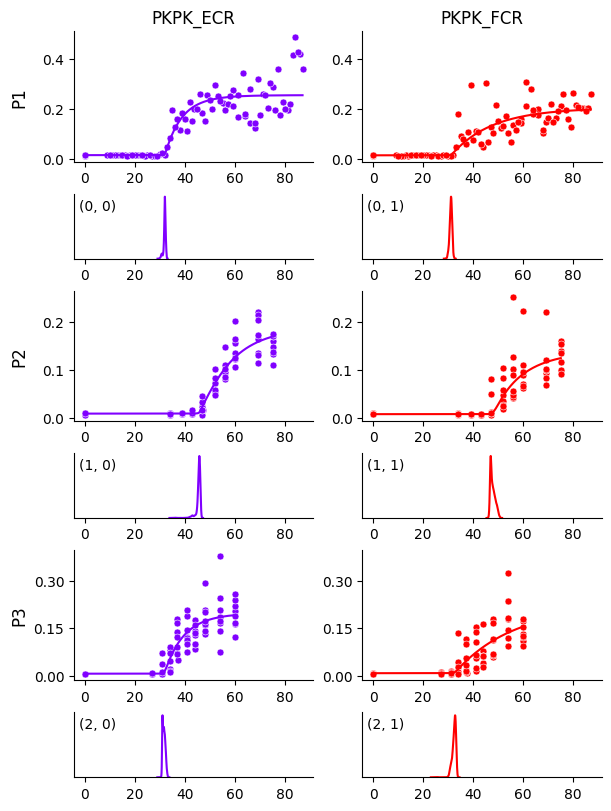

In [6]:
plot(
    df=df,
    **model.variables,
    encoder=encoder,
    posterior=posterior,
    prediction_df=prediction_df,
    predictive=predictive,
    predictive_hdi_prob=0.95,
)


We see that the curve for participant P1 and muscle FCR is no longer biased by those few data points, compared to {ref}`getting_started`. This becomes even clearer when we plot the HDIs around the curves below.


In [7]:
# Plot observations HDI
output_path = os.path.join(output_dir, "obs_hdi.pdf")
model.plot_curves(
    df=df,
    prediction_df=prediction_df,
    predictive=predictive,
    posterior=posterior,
    encoder=encoder,
    output_path="mixture_obs_hdi.pdf",
    predictive_hdi_var=mep.site.obs,
    predictive_hdi_prob=0.95
)

2026-04-19 00:16:40,315 - hbmep.model.base_model - INFO - Plotting curves...
2026-04-19 00:16:40,316 - hbmep.model.base_model - INFO - mixture_obs_hdi.pdf
2026-04-19 00:16:41,975 - hbmep.plotter - INFO - Page 1 of 1 done.
2026-04-19 00:16:41,979 - hbmep.util.util - INFO - Saving pdf...
2026-04-19 00:16:42,432 - hbmep.util.util - INFO - Saved to mixture_obs_hdi.pdf
2026-04-19 00:16:42,432 - hbmep.util.util - INFO - func:plot_curves took: 2.12 sec


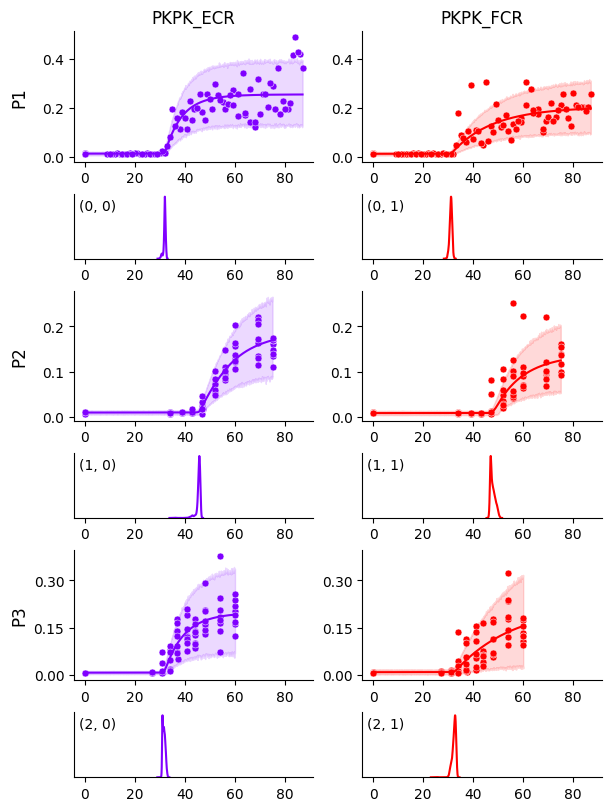

In [8]:
plot(
    df=df,
    **model.variables,
    encoder=encoder,
    posterior=posterior,
    prediction_df=prediction_df,
    predictive=predictive,
    predictive_hdi_var=mep.site.obs,
    predictive_hdi_prob=0.95,
)
